In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Obesity_Data_clean.csv')
print('Dataset shape:', df.shape)
df.head()
df.info()

Dataset shape: (2087, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             2087 non-null   str    
 1   age                2087 non-null   float64
 2   height             2087 non-null   float64
 3   weight             2087 non-null   float64
 4   family_history     2087 non-null   str    
 5   high_cal_food      2087 non-null   str    
 6   veg_consumption    2087 non-null   float64
 7   meals_per_day      2087 non-null   float64
 8   snacking           2087 non-null   str    
 9   smoking            2087 non-null   str    
 10  water_intake       2087 non-null   float64
 11  calorie_monitor    2087 non-null   str    
 12  physical_activity  2087 non-null   float64
 13  screen_time        2087 non-null   float64
 14  alcohol            2087 non-null   str    
 15  transport          2087 non-null   str    
 16  obesity_l

obesity_level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


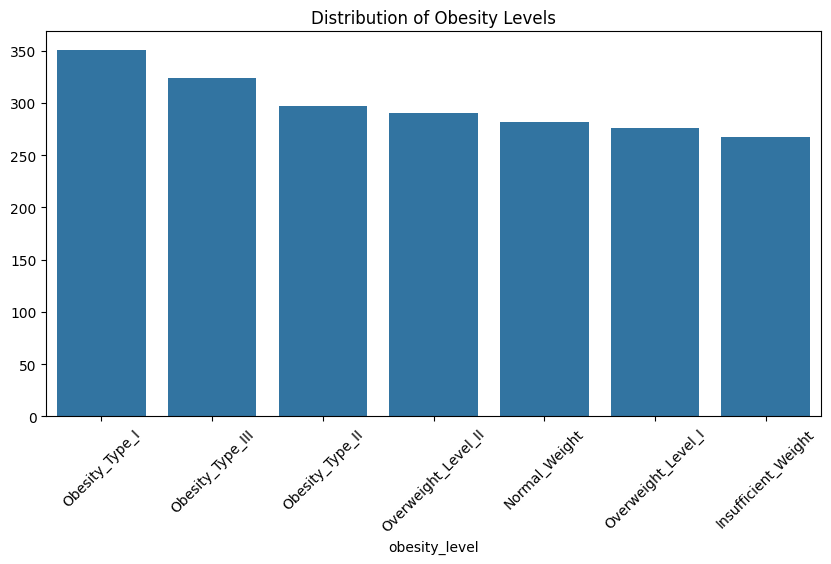

In [5]:
target_counts = df['obesity_level'].value_counts()
print(target_counts)
plt.figure(figsize=(10,5))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.show()

In [8]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

binary_cols = ['family_history', 'high_cal_food', 'smoking', 'calorie_monitor']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
print("Binary features encoded.")

categorical_cols = ['gender', 'snacking', 'alcohol', 'transport']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("One-hot encoding done. Current shape:", df.shape)

Binary features encoded.
One-hot encoding done. Current shape: (2087, 24)


In [10]:
le = LabelEncoder()
df['obesity_level'] = le.fit_transform(df['obesity_level'])
class_names = le.classes_
print("Target variable encoded. Class mapping:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

X = df.drop('obesity_level', axis=1)
y = df['obesity_level']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Target variable encoded. Class mapping:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II
Features shape: (2087, 23)
Target shape: (2087,)
Training set size: (1669, 23)
Test set size: (418, 23)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []
best_model = None
best_f1 = 0
best_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, acc, f1])
    print(f"{name}: Accuracy = {acc:.4f}, F1-score = {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_name = name

result_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-score'])
print("\nModel Comparison:")
print(result_df)

C:\Users\榴莲美少女\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.8397, F1-score = 0.8357
Decision Tree: Accuracy = 0.8301, F1-score = 0.8285
Random Forest: Accuracy = 0.9522, F1-score = 0.9533
XGBoost: Accuracy = 0.9689, F1-score = 0.9690

Model Comparison:
                 Model  Accuracy  F1-score
0  Logistic Regression  0.839713  0.835749
1        Decision Tree  0.830144  0.828484
2        Random Forest  0.952153  0.953263
3              XGBoost  0.968900  0.968982


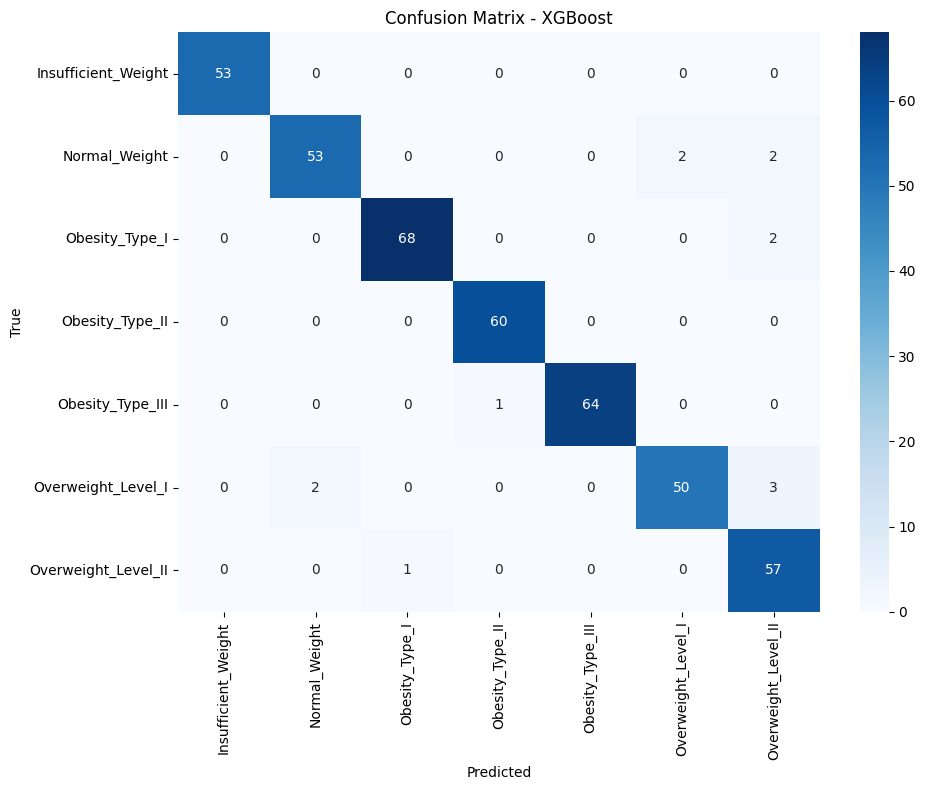


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.96      0.93      0.95        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.91      0.93        55
Overweight_Level_II       0.89      0.98      0.93        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



In [12]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names))


Top 10 Important Features:
              feature  importance
2              weight    0.288769
0                 age    0.098266
1              height    0.091875
5     veg_consumption    0.086639
12        gender_Male    0.061722
6       meals_per_day    0.053584
11        screen_time    0.049616
10  physical_activity    0.049432
8        water_intake    0.049365
3      family_history    0.032370


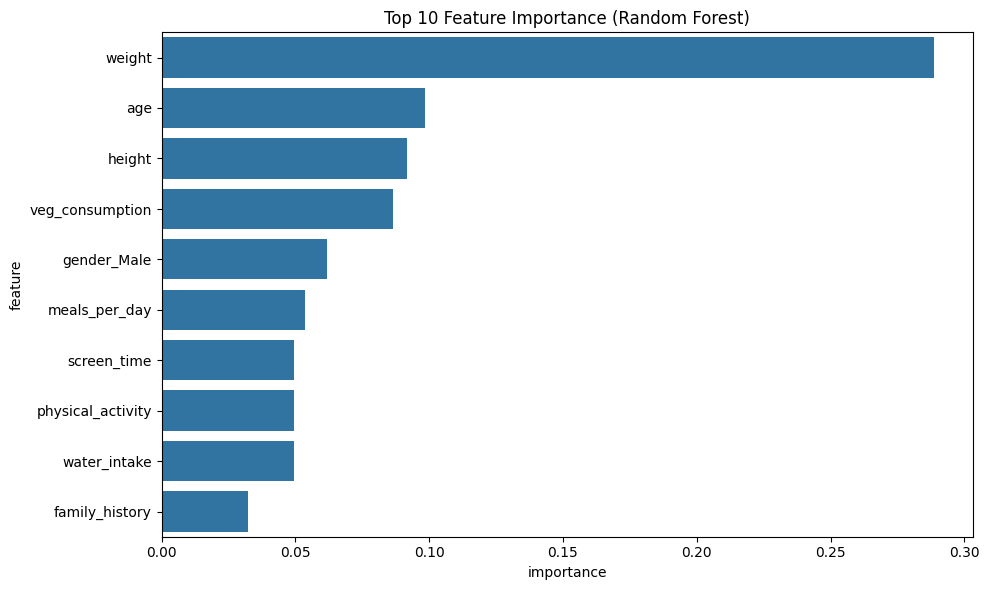

In [13]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feat_imp.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10))
plt.title('Top 10 Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()